# 04 — Seq2Point (perte MSE vs perte combinée multi-tâche)

**Objectif.** Entraîner Seq2Point (Zhang et al. 2018) par appareil, et **comparer deux
fonctions de perte** à architecture constante :
- `mse` : perte MSE classique sur la puissance (baseline).
- `combined` : MSE(puissance) + λ·BCE(état ON/OFF), via une **seconde sortie** de détection.
  Force le modèle à s'engager sur ON/OFF au lieu de se "cacher dans les zéros" (problème du
  déséquilibre de classe observé sur les appareils rares). Idée multi-tâche inspirée
  d'UNet-NILM, greffée sur Seq2Point sans changer le corps convolutif.

**Pourquoi cette comparaison ?** En MSE pure, les appareils rares (dishwasher, microwave)
obtiennent une perte basse en prédisant ~0 partout, sans détecter les cycles (erreur énergie
explosive, F1 effondré). La perte combinée traite ce biais. La comparaison
`mse` vs `combined` à architecture identique isole proprement l'effet de la perte.

**Local ou Colab GPU.** Détection device automatique. Pour Colab : §0bis (montage Drive) +
runtime GPU. Aucune dépendance NILMTK (lit les `.npz` du notebook 02).

**Protocole inter-foyers.** Train UK-DALE 1,2,4 ; test UK-DALE 5 (jamais vue).

## 0 — Configuration et imports

In [1]:
import warnings, json, time
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("torch", torch.__version__)
DEVICE = "cuda" if torch.cuda.is_available() else (
    "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cpu")
print("device :", DEVICE)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

torch 2.11.0+cu128
device : cuda


### 0bis — (Optionnel) Google Colab + GPU

Décommenter pour monter le Drive. Uploader `data/processed/` dans
`MyDrive/.../projet-nilm/data/processed/`. Activer un runtime GPU
(Exécution → Modifier le type d'exécution → GPU).

In [2]:
# --- COLAB (optionnel) : decommente ---
from google.colab import drive
drive.mount("/content/drive")
BASE_DIR = Path("/content/drive/MyDrive/Projet_scientifique/projet-nilm")
print("Si local : BASE_DIR = '..' (cellule suivante).")

Mounted at /content/drive
Si local : BASE_DIR = '..' (cellule suivante).


In [3]:
try:
    BASE_DIR
except NameError:
    BASE_DIR = Path("..")

DATA_DIR = BASE_DIR / "data"
PROC_DIR = DATA_DIR / "processed"
SEQ_DIR  = PROC_DIR / "seq2point"
MODELS_DIR = BASE_DIR / "models"; MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR    = BASE_DIR / "outputs" / "seq2point"; OUT_DIR.mkdir(parents=True, exist_ok=True)

manifest = json.load(open(PROC_DIR / "manifest.json"))
norm_params = json.load(open(PROC_DIR / "norm_params.json"))
WINDOW_SIZE   = manifest["params"]["window_size"]
SAMPLE_PERIOD = manifest["params"]["target_sample_period_s"]
ON_THRESHOLDS = manifest["params"]["on_power_thresholds"]
print("WINDOW_SIZE :", WINDOW_SIZE, "| SAMPLE_PERIOD :", SAMPLE_PERIOD, "s")
print("Artefacts :", PROC_DIR.resolve())

WINDOW_SIZE : 599 | SAMPLE_PERIOD : 6 s
Artefacts : /content/drive/MyDrive/Projet_scientifique/projet-nilm/data/processed


## 1 — Configuration

**`LOSS_MODE`** sélectionne la perte : `"mse"` (baseline) ou `"combined"` (multi-tâche).
Les métriques sont sauvegardées dans `metrics_{LOSS_MODE}.json` et les modèles dans
`models/{LOSS_MODE}/` → les deux variantes coexistent sans s'écraser, pour la comparaison
finale.

**Strides bas** (GPU le permet) : ~6-12× plus de fenêtres qu'avec stride 60. Sur T4, prévoir
~30-60 s/epoch. **`SKIP_IF_TRAINED`** saute un appareil déjà entraîné *dans ce mode de perte*.

In [4]:
DATASET = "UK-DALE"
LOSS_MODE = "combined"      # "mse" ou "combined"
LAMBDA_BCE = 0.1            # poids du terme de detection (combined uniquement)

APPLIANCES = ["fridge", "washing machine", "dish washer", "microwave", "kettle"]

# Strides bas (GPU). Appareils rares -> stride le plus fin.
STRIDES = {
    "fridge": 10, "washing machine": 8,
    "dish washer": 5, "microwave": 5, "kettle": 8,
}
STRIDE_TEST = 20            # test : un peu plus grossier (metriques stables, plus rapide)

BATCH_SIZE   = 512          # T4 : large batch
EPOCHS       = 15
LR           = 1e-3
VAL_FRACTION = 0.15
PATIENCE     = 4
NUM_WORKERS  = 2
SKIP_IF_TRAINED = False     # True une fois un mode entraine, pour ne pas le refaire

# dossiers par mode de perte
MODE_MODELS = MODELS_DIR / LOSS_MODE; MODE_MODELS.mkdir(parents=True, exist_ok=True)
results_file = OUT_DIR / f"metrics_{LOSS_MODE}.json"

print(f"LOSS_MODE = {LOSS_MODE} | lambda_bce = {LAMBDA_BCE}")
print("Strides :", STRIDES, "| batch", BATCH_SIZE, "| epochs", EPOCHS)
print("Metriques ->", results_file.name, "| modeles ->", MODE_MODELS)

LOSS_MODE = combined | lambda_bce = 0.1
Strides : {'fridge': 10, 'washing machine': 8, 'dish washer': 5, 'microwave': 5, 'kettle': 8} | batch 512 | epochs 15
Metriques -> metrics_combined.json | modeles -> /content/drive/MyDrive/Projet_scientifique/projet-nilm/models/combined


## 2 — Dataset, modèle, pertes

Le `Dataset` renvoie aussi l'**état ON/OFF** de la cible (pour la perte combinée). Le modèle
`Seq2Point` a deux têtes : puissance (régression) et logit d'état (classification). En mode
`mse`, la tête d'état est ignorée.

In [5]:
class Seq2PointDataset(Dataset):
    def __init__(self, npz_path, norm, appliance, threshold, window=599, stride=1):
        d = np.load(npz_path, allow_pickle=True)
        self.mains   = d["mains"].astype(np.float32)
        self.target  = d["target"].astype(np.float32)
        self.offsets = d["offsets"].astype(np.int64)
        self.L = window; self.half = window // 2
        self.thr = threshold
        self.mu_m, self.sd_m = norm["mains"]["mean"], norm["mains"]["std"]
        self.mu_a = norm["appliances"][appliance]["mean"]
        self.sd_a = norm["appliances"][appliance]["std"]
        idx = []
        for s, e in zip(self.offsets[:-1], self.offsets[1:]):
            n = e - s
            if n < window: continue
            for p in range(0, n - window + 1, stride):
                idx.append((s + p, s + p + self.half))
        self.index = np.array(idx, dtype=np.int64)

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        start, center = self.index[i]
        x = (self.mains[start:start + self.L] - self.mu_m) / self.sd_m
        p_watt = self.target[center]
        y = (p_watt - self.mu_a) / self.sd_a            # puissance normalisee
        state = 1.0 if p_watt > self.thr else 0.0       # etat ON/OFF
        return (torch.from_numpy(x).unsqueeze(0),
                torch.tensor(y, dtype=torch.float32),
                torch.tensor(state, dtype=torch.float32))


class Seq2Point(nn.Module):
    def __init__(self, window=599):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1,  30, 10, padding="same"), nn.ReLU(),
            nn.Conv1d(30, 30, 8,  padding="same"), nn.ReLU(),
            nn.Conv1d(30, 40, 6,  padding="same"), nn.ReLU(),
            nn.Conv1d(40, 50, 5,  padding="same"), nn.ReLU(),
            nn.Conv1d(50, 50, 5,  padding="same"), nn.ReLU(),
        )
        self.shared = nn.Sequential(nn.Flatten(), nn.Linear(50 * window, 1024), nn.ReLU())
        self.head_power = nn.Linear(1024, 1)    # regression puissance
        self.head_state = nn.Linear(1024, 1)    # logit ON/OFF

    def forward(self, x):
        h = self.shared(self.conv(x))
        return self.head_power(h).squeeze(-1), self.head_state(h).squeeze(-1)

print("Classes definies.")

Classes definies.


In [6]:
def make_loaders(appliance):
    norm = norm_params[DATASET]
    col = appliance.replace(" ", "_")
    thr = ON_THRESHOLDS[appliance]
    tr_path = SEQ_DIR / f"{col}__{DATASET}__train.npz"
    te_path = SEQ_DIR / f"{col}__{DATASET}__test.npz"
    if not tr_path.exists() or not te_path.exists():
        return None, None, None
    full = Seq2PointDataset(tr_path, norm, appliance, thr, WINDOW_SIZE, STRIDES[appliance])
    test = Seq2PointDataset(te_path, norm, appliance, thr, WINDOW_SIZE, STRIDE_TEST)
    n_val = int(len(full) * VAL_FRACTION); n_tr = len(full) - n_val
    g = torch.Generator().manual_seed(SEED)
    tr_set, va_set = torch.utils.data.random_split(full, [n_tr, n_val], generator=g)
    common = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))
    return (DataLoader(tr_set, BATCH_SIZE, shuffle=True,  **common),
            DataLoader(va_set, BATCH_SIZE, shuffle=False, **common),
            DataLoader(test,   BATCH_SIZE, shuffle=False, **common)), test, len(full)


mse_fn = nn.MSELoss()
bce_fn = nn.BCEWithLogitsLoss()

def compute_loss(pred_power, pred_state, y_power, y_state):
    if LOSS_MODE == "mse":
        return mse_fn(pred_power, y_power)
    # combined : MSE puissance + lambda * BCE etat
    return mse_fn(pred_power, y_power) + LAMBDA_BCE * bce_fn(pred_state, y_state)

def run_epoch(model, loader, opt=None):
    train = opt is not None
    model.train(train)
    total, n = 0.0, 0
    for x, y, st in loader:
        x, y, st = x.to(DEVICE), y.to(DEVICE), st.to(DEVICE)
        if train: opt.zero_grad()
        pp, ps = model(x)
        loss = compute_loss(pp, ps, y, st)
        if train: loss.backward(); opt.step()
        total += loss.item() * len(y); n += len(y)
    return total / max(n, 1)

@torch.no_grad()
def predict(model, loader):
    model.eval()
    P, T = [], []
    for x, y, st in loader:
        pp, _ = model(x.to(DEVICE))
        P.append(pp.cpu().numpy()); T.append(y.numpy())
    return np.concatenate(P), np.concatenate(T)

def compute_metrics(pred_w, true_w, thr):
    mae = float(np.mean(np.abs(pred_w - true_w)))
    on_p, on_t = pred_w > thr, true_w > thr
    tp = np.sum(on_p & on_t); fp = np.sum(on_p & ~on_t); fn = np.sum(~on_p & on_t)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    Et = true_w.sum() * SAMPLE_PERIOD / 3600.0
    Ep = pred_w.sum() * SAMPLE_PERIOD / 3600.0
    eerr = abs(Ep - Et) / Et if Et else float("nan")
    return dict(mae_w=mae, f1=f1, precision=float(prec), recall=float(rec),
                energy_err_pct=float(eerr * 100))

print("Fonctions definies.")

Fonctions definies.


## 3 — Boucle d'entraînement

Pour chaque appareil : loaders, entraînement (early stopping sur val), évaluation
inter-foyers, sauvegarde. Métriques accumulées dans `metrics_{LOSS_MODE}.json`.

In [7]:
all_results = json.load(open(results_file)) if results_file.exists() else {}
histories = {}

for appliance in APPLIANCES:
    col = appliance.replace(" ", "_")
    ckpt = MODE_MODELS / f"seq2point_{col}_{DATASET}.pt"
    print(f"\n{'='*60}\n{appliance.upper()}  [{LOSS_MODE}]  (stride {STRIDES[appliance]})\n{'='*60}")

    loaders, test_set, n_full = make_loaders(appliance)
    if loaders is None:
        print(f"  séquences absentes -> skip"); continue
    train_loader, val_loader, test_loader = loaders
    print(f"  fenetres train : {n_full:,} | test : {len(test_set):,}")

    model = Seq2Point(WINDOW_SIZE).to(DEVICE)

    if SKIP_IF_TRAINED and ckpt.exists():
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        print(f"  checkpoint existant -> pas de reentrainement")
        histories[appliance] = None; best_val = float("nan")
    else:
        opt = torch.optim.Adam(model.parameters(), lr=LR)
        best_val, best_state, bad = float("inf"), None, 0
        hist = {"train": [], "val": []}
        for ep in range(1, EPOCHS + 1):
            t0 = time.time()
            tr = run_epoch(model, train_loader, opt)
            va = run_epoch(model, val_loader, None)
            hist["train"].append(tr); hist["val"].append(va)
            flag = ""
            if va < best_val:
                best_val = va; bad = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                torch.save(best_state, ckpt); flag = " <- best"
            else:
                bad += 1
            print(f"  epoch {ep:2d}/{EPOCHS} | train {tr:.4f} | val {va:.4f} | "
                  f"{time.time()-t0:.0f}s{flag}")
            if bad >= PATIENCE:
                print(f"  early stopping (patience {PATIENCE})"); break
        if best_state is not None:
            model.load_state_dict(best_state)
        histories[appliance] = hist

    pred_n, true_n = predict(model, test_loader)
    pred_w = np.clip(pred_n * test_set.sd_a + test_set.mu_a, 0, None)
    true_w = true_n * test_set.sd_a + test_set.mu_a
    m = compute_metrics(pred_w, true_w, ON_THRESHOLDS[appliance])

    all_results[f"{appliance}__{DATASET}"] = {
        "appliance": appliance, "dataset": DATASET, "loss_mode": LOSS_MODE,
        **{k: round(v, 4) for k, v in m.items()},
        "stride_train": STRIDES[appliance], "stride_test": STRIDE_TEST,
        "best_val": (None if best_val != best_val else round(float(best_val), 5)),
        "checkpoint": str(ckpt.as_posix()),
    }
    json.dump(all_results, open(results_file, "w"), indent=2)
    print(f"  -> MAE {m['mae_w']:.1f}W | F1 {m['f1']:.3f} | energie {m['energy_err_pct']:.1f}%")

print("\nTermine. Metriques :", results_file)


FRIDGE  [combined]  (stride 10)
  fenetres train : 193,262 | test : 29,248
  epoch  1/15 | train 0.7060 | val 0.7049 | 26s <- best
  epoch  2/15 | train 0.5857 | val 0.6664 | 25s <- best
  epoch  3/15 | train 0.5502 | val 0.6342 | 27s <- best
  epoch  4/15 | train 0.5013 | val 0.6323 | 29s <- best
  epoch  5/15 | train 0.4672 | val 0.5760 | 28s <- best
  epoch  6/15 | train 0.4255 | val 0.5583 | 27s <- best
  epoch  7/15 | train 0.3653 | val 0.5367 | 28s <- best
  epoch  8/15 | train 0.3164 | val 0.5168 | 28s <- best
  epoch  9/15 | train 0.2611 | val 0.5448 | 27s
  epoch 10/15 | train 0.2076 | val 0.6141 | 27s
  epoch 11/15 | train 0.1806 | val 0.5514 | 27s
  epoch 12/15 | train 0.1707 | val 0.5561 | 27s
  early stopping (patience 4)
  -> MAE 24.5W | F1 0.826 | energie 0.8%

WASHING MACHINE  [combined]  (stride 8)
  fenetres train : 240,262 | test : 33,883
  epoch  1/15 | train 0.5572 | val 0.2656 | 34s <- best
  epoch  2/15 | train 0.2246 | val 0.1803 | 34s <- best
  epoch  3/15 | t

## 4 — Synthèse du mode courant

In [8]:
res_df = pd.DataFrame([v for v in all_results.values() if v["dataset"] == DATASET])
res_df = res_df[["appliance", "mae_w", "f1", "precision", "recall",
                 "energy_err_pct", "stride_train"]].sort_values("f1", ascending=False)
print(f"Mode de perte : {LOSS_MODE}")
res_df

Mode de perte : combined


,appliance,mae_w,f1,precision,recall,energy_err_pct,stride_train
4,kettle,9.2448,0.8496,0.9262,0.7847,27.4615,8
0,fridge,24.4855,0.8258,0.8487,0.8041,0.7914,10
2,dish washer,20.4124,0.3668,0.2356,0.8285,46.3693,5
1,washing machine,31.4070,0.3461,0.2395,0.6243,45.3708,8
3,microwave,51.6067,0.0257,0.0132,0.5000,68.3533,5


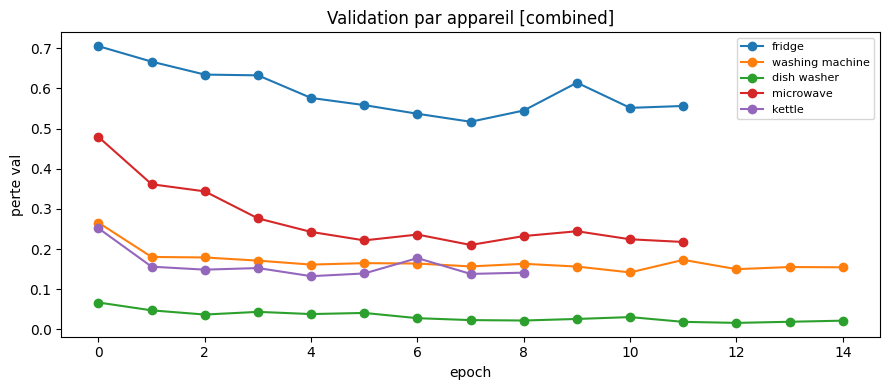

In [9]:
trained = {a: h for a, h in histories.items() if h is not None}
if trained:
    fig, ax = plt.subplots(figsize=(9, 4))
    for a, h in trained.items():
        ax.plot(h["val"], marker="o", label=f"{a}")
    ax.set_xlabel("epoch"); ax.set_ylabel("perte val")
    ax.set_title(f"Validation par appareil [{LOSS_MODE}]")
    ax.legend(fontsize=8); plt.tight_layout()
    plt.savefig(OUT_DIR / f"val_curves_{LOSS_MODE}.png", dpi=120); plt.show()

## 5 — Comparaison MSE vs combinée

Si les deux modes ont été exécutés (`metrics_mse.json` **et** `metrics_combined.json`
présents), cette cellule les confronte appareil par appareil. C'est le résultat clé pour le
rapport : effet de la perte à architecture constante.

,appliance,F1_mse,F1_comb,MAE_mse,MAE_comb,Eerr_mse,Eerr_comb
0,fridge,0.7779,0.8258,29.0454,24.4855,16.3506,0.7914
1,washing machine,0.2409,0.3461,44.7973,31.4070,5.7063,45.3708
2,dish washer,0.2111,0.3668,30.4676,20.4124,143.9869,46.3693
3,microwave,0.0241,0.0257,46.8195,51.6067,71.0245,68.3533
4,kettle,0.7089,0.8496,9.1305,9.2448,19.2298,27.4615


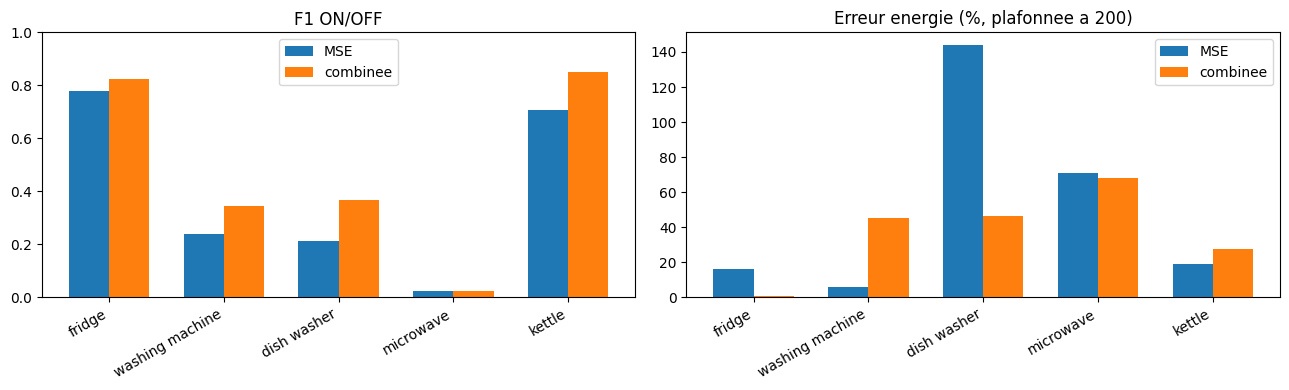

In [10]:
def load_mode(mode):
    f = OUT_DIR / f"metrics_{mode}.json"
    if not f.exists():
        return None
    d = json.load(open(f))
    return {v["appliance"]: v for v in d.values() if v["dataset"] == DATASET}

mse_r, comb_r = load_mode("mse"), load_mode("combined")
if mse_r and comb_r:
    rows = []
    for app in APPLIANCES:
        if app in mse_r and app in comb_r:
            rows.append({
                "appliance": app,
                "F1_mse": mse_r[app]["f1"], "F1_comb": comb_r[app]["f1"],
                "MAE_mse": mse_r[app]["mae_w"], "MAE_comb": comb_r[app]["mae_w"],
                "Eerr_mse": mse_r[app]["energy_err_pct"],
                "Eerr_comb": comb_r[app]["energy_err_pct"],
            })
    cmp_df = pd.DataFrame(rows)
    display(cmp_df)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    x = np.arange(len(cmp_df)); w = 0.35
    axes[0].bar(x - w/2, cmp_df["F1_mse"], w, label="MSE")
    axes[0].bar(x + w/2, cmp_df["F1_comb"], w, label="combinee")
    axes[0].set_xticks(x); axes[0].set_xticklabels(cmp_df["appliance"], rotation=30, ha="right")
    axes[0].set_title("F1 ON/OFF"); axes[0].set_ylim(0, 1); axes[0].legend()
    axes[1].bar(x - w/2, np.clip(cmp_df["Eerr_mse"], 0, 200), w, label="MSE")
    axes[1].bar(x + w/2, np.clip(cmp_df["Eerr_comb"], 0, 200), w, label="combinee")
    axes[1].set_xticks(x); axes[1].set_xticklabels(cmp_df["appliance"], rotation=30, ha="right")
    axes[1].set_title("Erreur energie (%, plafonnee a 200)"); axes[1].legend()
    plt.tight_layout(); plt.savefig(OUT_DIR / "comparaison_mse_vs_combined.png", dpi=120); plt.show()
else:
    have = [m for m, r in [("mse", mse_r), ("combined", comb_r)] if r]
    print("Modes disponibles :", have)
    print("Lance les DEUX modes (LOSS_MODE='mse' puis 'combined') pour la comparaison.")

## 6 — Démarche et points pour le rapport

**Pour obtenir la comparaison complète :**
1. `LOSS_MODE = "mse"` → Run All (baseline ; ~30-40 min T4). Produit `metrics_mse.json`.
2. `LOSS_MODE = "combined"` → Run All. Produit `metrics_combined.json`.
3. La §5 confronte automatiquement les deux.

**À analyser dans la suite :**
- **Effet de la perte combinée** sur les appareils rares (dishwasher, microwave) : le terme
  BCE doit relever le F1 et surtout corriger l'erreur énergie (144 % en MSE pure pour le
  dishwasher). Vérifier le gain réel.
- **λ (LAMBDA_BCE)** : 0,1 par défaut. Trop haut → le modèle privilégie la détection au
  détriment de la précision en puissance (MAE remonte). Tester 0,05 / 0,2 si besoin.
- **Microwave** : test UK-DALE h5 très pauvre (~14 cycles) → métriques peu robustes quelle
  que soit la perte. À documenter comme limite du split, pas comme échec du modèle.
- **GPU** : `num_workers=2`, `pin_memory`, batch 512 → meilleure occupation T4. Monter le
  batch si la VRAM le permet (T4 = 16 Go).

**Suite :**
- `06_evaluation_comparaison` : agréger les `metrics_*.json`, comparer aux baselines NILMTK.
- `07_ablation_resolution` : dégrader 6s → 30min (question Linky).